<a href="https://colab.research.google.com/github/Angelo-chi/chord-progression-analyzer/blob/main/final_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install librosa matplotlib numpy tensorflow pandas yt-dlp
!apt-get install ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.3/173.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, LSTM, Dense, Dropout, Reshape, Flatten, Input
import pandas as pd
import glob
import os
from google.colab import drive
from tensorflow.keras.callbacks import EarlyStopping

# 掛載Google Drive
drive.mount('/content/drive')

# 音級名稱
PITCH_CLASSES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

# 加載Isophonics數據
def load_isophonics_data(isophonics_path, max_length=50):
    X, y, chord_list = [], [], []
    isophonics_files = glob.glob(os.path.join(isophonics_path, "**/*.lab"), recursive=True)
    if not isophonics_files:
        print(f"No .lab files found in {isophonics_path}")
        return np.array([]), np.array([]), []

    chord_templates = {
        f"{root}_{typ}": np.zeros(12) for root in PITCH_CLASSES for typ in ["major", "minor", "7", "sus4"]
    }
    for root_idx, root in enumerate(PITCH_CLASSES):
        chord_templates[f"{root}_major"][[root_idx, (root_idx + 4) % 12, (root_idx + 7) % 12]] = 1
        chord_templates[f"{root}_minor"][[root_idx, (root_idx + 3) % 12, (root_idx + 7) % 12]] = 1
        chord_templates[f"{root}_7"][[root_idx, (root_idx + 4) % 12, (root_idx + 7) % 12, (root_idx + 10) % 12]] = 1
        chord_templates[f"{root}_sus4"][[root_idx, (root_idx + 5) % 12, (root_idx + 7) % 12]] = 1
    chord_list = list(chord_templates.keys())

    for lab_file in isophonics_files[:5]:  # 限制為前5首以加速測試
        base_dir = os.path.dirname(lab_file)
        base_name = os.path.basename(lab_file).replace(".lab", "")
        audio_file = os.path.join(base_dir, f"{base_name}.mp3")
        if not os.path.exists(audio_file):
            print(f"Skipping {lab_file}: No audio file")
            continue

        audio, sr = librosa.load(audio_file)
        chroma = librosa.feature.chroma_cens(y=audio, sr=sr, hop_length=512)
        labels = pd.read_csv(lab_file, sep="\s+", header=None, names=["start", "end", "chord"])
        for _, row in labels.iterrows():
            start_idx = int(row["start"] * sr / 512)
            end_idx = int(row["end"] * sr / 512)
            if end_idx <= start_idx or end_idx > chroma.shape[1]:
                continue
            segment = chroma[:, start_idx:end_idx]
            if segment.shape[1] < 5:
                continue
            if segment.shape[1] < max_length:
                pad_width = ((0, 0), (0, max_length - segment.shape[1]))
                segment = np.pad(segment, pad_width, mode='constant')
            else:
                segment = segment[:, :max_length]
            chord = row["chord"].replace(":maj", "_major").replace(":min", "_minor").replace(":7", "7")
            if chord in chord_list:
                X.append(segment)
                y.append(chord_list.index(chord))
        print(f"加載 {lab_file} 後，X 長度: {len(X)}, y 長度: {len(y)}")
    print("X 形狀:", np.array(X).shape, "y 形狀:", np.array(y).shape)
    return np.array(X), np.array(y), chord_list

# 構建CRNN模型
def build_crnn_model(input_shape=(50, 12, 1), n_classes=48):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    conv_output_shape = tf.keras.backend.int_shape(x)[1:]
    time_steps = np.prod(conv_output_shape)
    x = Reshape((-1, time_steps))(x)
    x = LSTM(128, return_sequences=False)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 主訓練函數
isophonics_path = "/content/drive/MyDrive/isophonics"
X, y, chord_list = load_isophonics_data(isophonics_path, max_length=50)
print(f"加載了 {len(X)} 個訓練樣本，{len(chord_list)} 種和弦")

if len(X) > 0:
    X_padded = X.reshape(X.shape[0], X.shape[2], X.shape[1], 1)
    print("X_padded 形狀:", X_padded.shape)

    # 添加早停
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model = build_crnn_model(input_shape=(50, 12, 1), n_classes=len(chord_list))
    history = model.fit(X_padded, y, epochs=20, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

    # 保存模型
    model.save('/content/drive/MyDrive/chord_model.keras')
    print("模型訓練完成並保存至 /content/drive/MyDrive/chord_model.keras")

    # 驗證
    X_test = X_padded[:5]
    y_pred = model.predict(X_test)
    predicted_chords = [chord_list[np.argmax(pred)] for pred in y_pred]
    true_chords = [chord_list[i] for i in y[:5]]
    print("真實和弦（前5個樣本）：", true_chords)
    print("預測和弦（前5個樣本）：", predicted_chords)
else:
    print("無效數據，無法訓練模型。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
加載 /content/drive/MyDrive/isophonics/I'll Be Back.lab 後，X 長度: 15, y 長度: 15
加載 /content/drive/MyDrive/isophonics/You Can't Do That.lab 後，X 長度: 27, y 長度: 27
加載 /content/drive/MyDrive/isophonics/Tell Me Why.lab 後，X 長度: 72, y 長度: 72
加載 /content/drive/MyDrive/isophonics/A Hard Day's Night.lab 後，X 長度: 80, y 長度: 80
加載 /content/drive/MyDrive/isophonics/I Should Have Known Better.lab 後，X 長度: 92, y 長度: 92
X 形狀: (92, 12, 50) y 形狀: (92,)
加載了 92 個訓練樣本，48 種和弦
X_padded 形狀: (92, 50, 12, 1)
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.2053 - loss: 3.8268 - val_accuracy: 0.1579 - val_loss: 3.4927
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3981 - loss: 3.1340 - val_accuracy: 0.1579 - val_loss: 1.6924
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4219 - loss: 1.6887 - val_accuracy: 0.8421 - val_loss: 0.7614
Epoch 4/20
5/5 ━

In [ ]:
# 加載模型
model = tf.keras.models.load_model('/content/drive/MyDrive/chord_model.h5')

In [ ]:
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, LSTM, Dense, Dropout, Reshape, Flatten, Input, BatchNormalization
from tensorflow.keras.regularizers import l2
import pandas as pd
import glob
import os
from google.colab import drive
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import resample
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

# 掛載Google Drive
drive.mount('/content/drive')

# 音級名稱
PITCH_CLASSES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

# 加載Isophonics數據
def load_isophonics_data(isophonics_path, max_length=50):
    X, y, chord_list = [], [], []
    isophonics_files = glob.glob(os.path.join(isophonics_path, "**/*.lab"), recursive=True)
    if not isophonics_files:
        print(f"No .lab files found in {isophonics_path}")
        return np.array([]), np.array([]), []

    chord_templates = {
        f"{root}_{typ}": np.zeros(12) for root in PITCH_CLASSES for typ in ["major", "minor", "7", "sus4"]
    }
    for root_idx, root in enumerate(PITCH_CLASSES):
        chord_templates[f"{root}_major"][[root_idx, (root_idx + 4) % 12, (root_idx + 7) % 12]] = 1
        chord_templates[f"{root}_minor"][[root_idx, (root_idx + 3) % 12, (root_idx + 7) % 12]] = 1
        chord_templates[f"{root}_7"][[root_idx, (root_idx + 4) % 12, (root_idx + 7) % 12, (root_idx + 10) % 12]] = 1
        chord_templates[f"{root}_sus4"][[root_idx, (root_idx + 5) % 12, (root_idx + 7) % 12]] = 1
    chord_list = list(chord_templates.keys())

    for lab_file in isophonics_files:
        base_dir = os.path.dirname(lab_file)
        base_name = os.path.basename(lab_file).replace(".lab", "")
        audio_file = os.path.join(base_dir, f"{base_name}.mp3")
        if not os.path.exists(audio_file):
            print(f"Skipping {lab_file}: No audio file")
            continue

        audio, sr = librosa.load(audio_file)
        chroma = librosa.feature.chroma_cens(y=audio, sr=sr, hop_length=512)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        audio_shifted = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
        chroma_shifted = librosa.feature.chroma_cens(y=audio_shifted, sr=sr, hop_length=512)
        mfcc_shifted = librosa.feature.mfcc(y=audio_shifted, sr=sr, n_mfcc=13)
        labels = pd.read_csv(lab_file, sep="\s+", header=None, names=["start", "end", "chord"])
        for _, row in labels.iterrows():
            start_idx = int(row["start"] * sr / 512)
            end_idx = int(row["end"] * sr / 512)
            if end_idx <= start_idx or end_idx > chroma.shape[1]:
                continue
            segment_chroma = chroma[:, start_idx:end_idx]
            segment_mfcc = mfcc[:, start_idx:end_idx]
            segment_chroma_shifted = chroma_shifted[:, start_idx:end_idx]
            segment_mfcc_shifted = mfcc_shifted[:, start_idx:end_idx]
            if segment_chroma.shape[1] < 5:
                continue
            if segment_chroma.shape[1] < max_length:
                pad_width = ((0, 0), (0, max_length - segment_chroma.shape[1]))
                segment_chroma = np.pad(segment_chroma, pad_width, mode='constant')
                segment_mfcc = np.pad(segment_mfcc, pad_width, mode='constant')
                segment_chroma_shifted = np.pad(segment_chroma_shifted, pad_width, mode='constant')
                segment_mfcc_shifted = np.pad(segment_mfcc_shifted, pad_width, mode='constant')
            else:
                segment_chroma = segment_chroma[:, :max_length]
                segment_mfcc = segment_mfcc[:, :max_length]
                segment_chroma_shifted = segment_chroma_shifted[:, :max_length]
                segment_mfcc_shifted = segment_mfcc_shifted[:, :max_length]
            segment = np.concatenate([segment_chroma, segment_mfcc], axis=0)
            segment_shifted = np.concatenate([segment_chroma_shifted, segment_mfcc_shifted], axis=0)
            scaler = StandardScaler()
            segment = scaler.fit_transform(segment)
            segment_shifted = scaler.fit_transform(segment_shifted)
            chord = row["chord"].replace(":maj", "_major").replace(":min", "_minor").replace(":7", "7")
            if chord in chord_list:
                X.append(segment)
                X.append(segment_shifted)
                y.append(chord_list.index(chord))
                y.append(chord_list.index(chord))
        print(f"加載 {lab_file} 後，X 長度: {len(X)}, y 長度: {len(y)}")
    print("X 形狀:", np.array(X).shape, "y 形狀:", np.array(y).shape)
    print("和弦分佈:", Counter([chord_list[i] for i in y]))
    return np.array(X), np.array(y), chord_list

# 構建CRNN模型
def build_crnn_model(input_shape=(50, 25, 1), n_classes=48):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    conv_output_shape = tf.keras.backend.int_shape(x)[1:]
    time_steps = np.prod(conv_output_shape)
    x = Reshape((-1, time_steps))(x)
    x = LSTM(128, return_sequences=False)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 主訓練函數
isophonics_path = "/content/drive/MyDrive/isophonics"
X, y, chord_list = load_isophonics_data(isophonics_path, max_length=50)
print(f"加載了 {len(X)} 個訓練樣本，{len(chord_list)} 種和弦")

if len(X) > 0:
    X_padded = X.reshape(X.shape[0], X.shape[2], X.shape[1], 1)
    print("X_padded 形狀:", X_padded.shape)

    # 平衡類別
    majority_classes = [i for i, count in Counter(y).items() if count > 80]
    X_downsampled, y_downsampled = [], []
    for cls in majority_classes:
        cls_indices = np.where(y == cls)[0]
        X_cls = X[cls_indices]
        y_cls = y[cls_indices]
        X_downsampled_cls, y_downsampled_cls = resample(X_cls, y_cls, n_samples=80, random_state=42)
        X_downsampled.append(X_downsampled_cls)
        y_downsampled.append(y_downsampled_cls)
    minority_indices = [i for i in range(len(y)) if y[i] not in majority_classes]
    X = np.concatenate([X[minority_indices], X_downsampled])
    y = np.concatenate([y[minority_indices], y_downsampled])
    print("平衡後X形狀:", X.shape, "平衡後y形狀:", y.shape)

    X_padded = X.reshape(X.shape[0], X.shape[2], X.shape[1], 1)
    print("新X_padded 形狀:", X_padded.shape)

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)
    model = build_crnn_model(input_shape=(50, 25, 1), n_classes=len(chord_list))
    history = model.fit(X_padded, y, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

    model.save('/content/drive/MyDrive/chord_model.keras')
    print("模型訓練完成並保存至 /content/drive/MyDrive/chord_model.keras")

    # 驗證與混淆矩陣
    X_test = X_padded[:5]
    y_pred = model.predict(X_test)
    predicted_chords = [chord_list[np.argmax(pred)] for pred in y_pred]
    true_chords = [chord_list[i] for i in y[:5]]
    print("真實和弦（前5個樣本）：", true_chords)
    print("預測和弦（前5個樣本）：", predicted_chords)

    y_pred_all = model.predict(X_padded)
    y_pred_labels = [np.argmax(pred) for pred in y_pred_all]
    conf_matrix = confusion_matrix(y, y_pred_labels)
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
    print("正規化混淆矩陣:\n", conf_matrix_normalized)

    # 訓練曲線
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.show()

    # 特徵可視化
    fsharp_minor_idx = [i for i, label in enumerate(y) if chord_list[label] == 'F#_minor']
    e_minor_idx = [i for i, label in enumerate(y) if chord_list[label] == 'E_minor']
    plt.plot(X[fsharp_minor_idx].mean(axis=(0, 2)), label='F#_minor')
    plt.plot(X[e_minor_idx].mean(axis=(0, 2)), label='E_minor')
    plt.legend()
    plt.show()
else:
    print("無效數據，無法訓練模型。")

模型已從 /content/drive/MyDrive/chord_model.keras 加載並重新編譯
推測調性：G_major
節奏分析： 估計BPM: 205.08, 平均間隔: 292.57 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


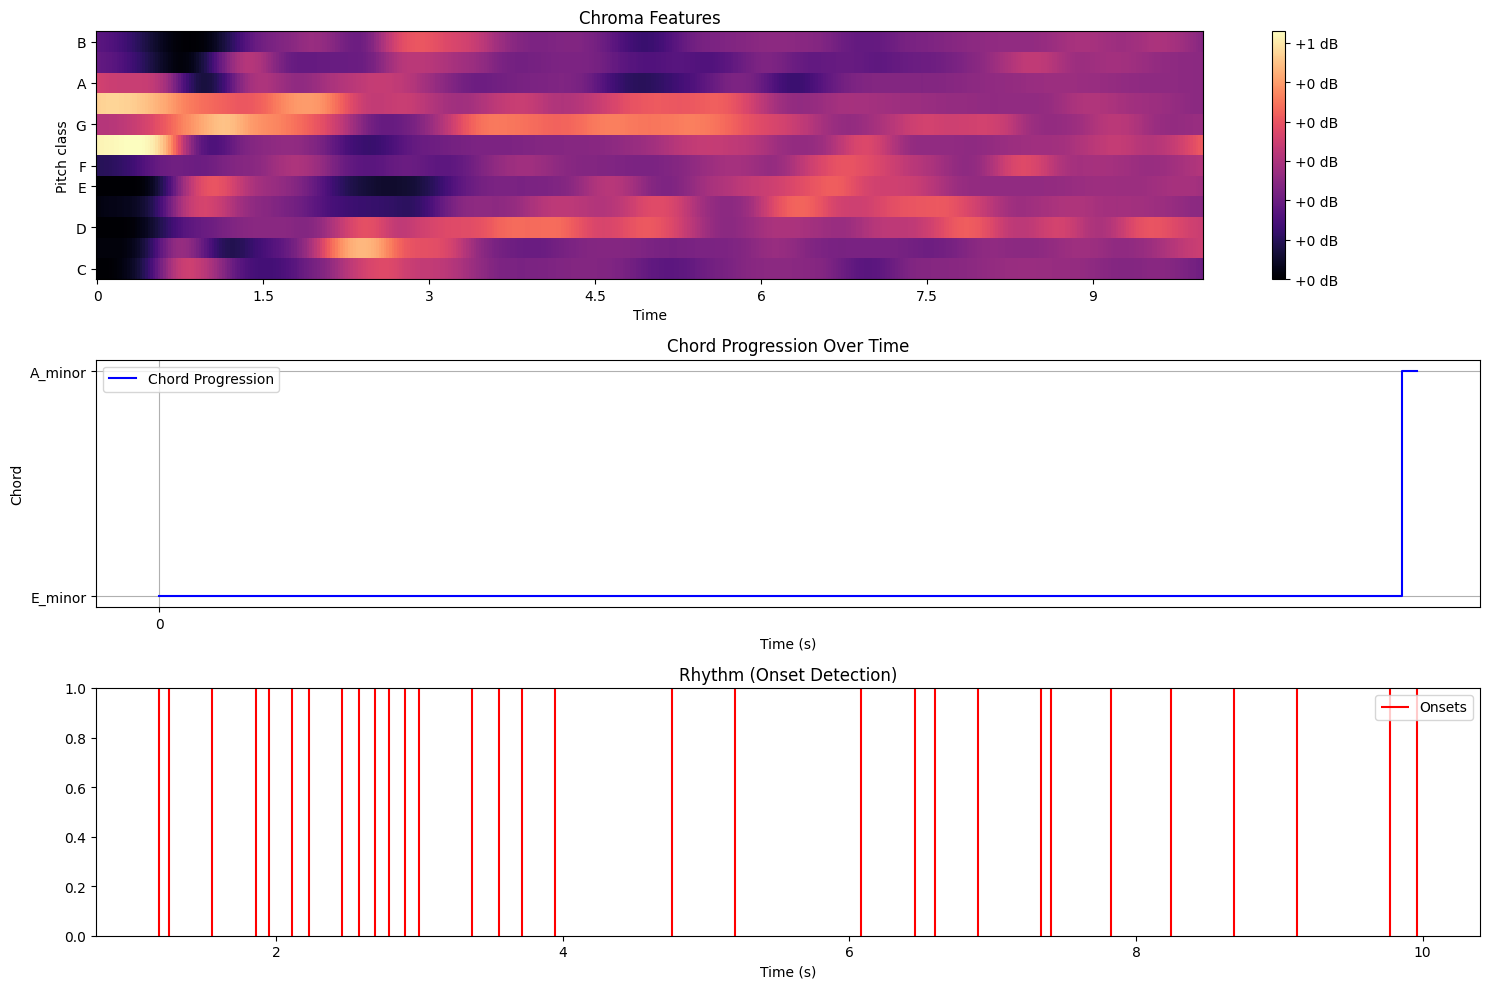

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 211.19, 平均間隔: 284.10 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


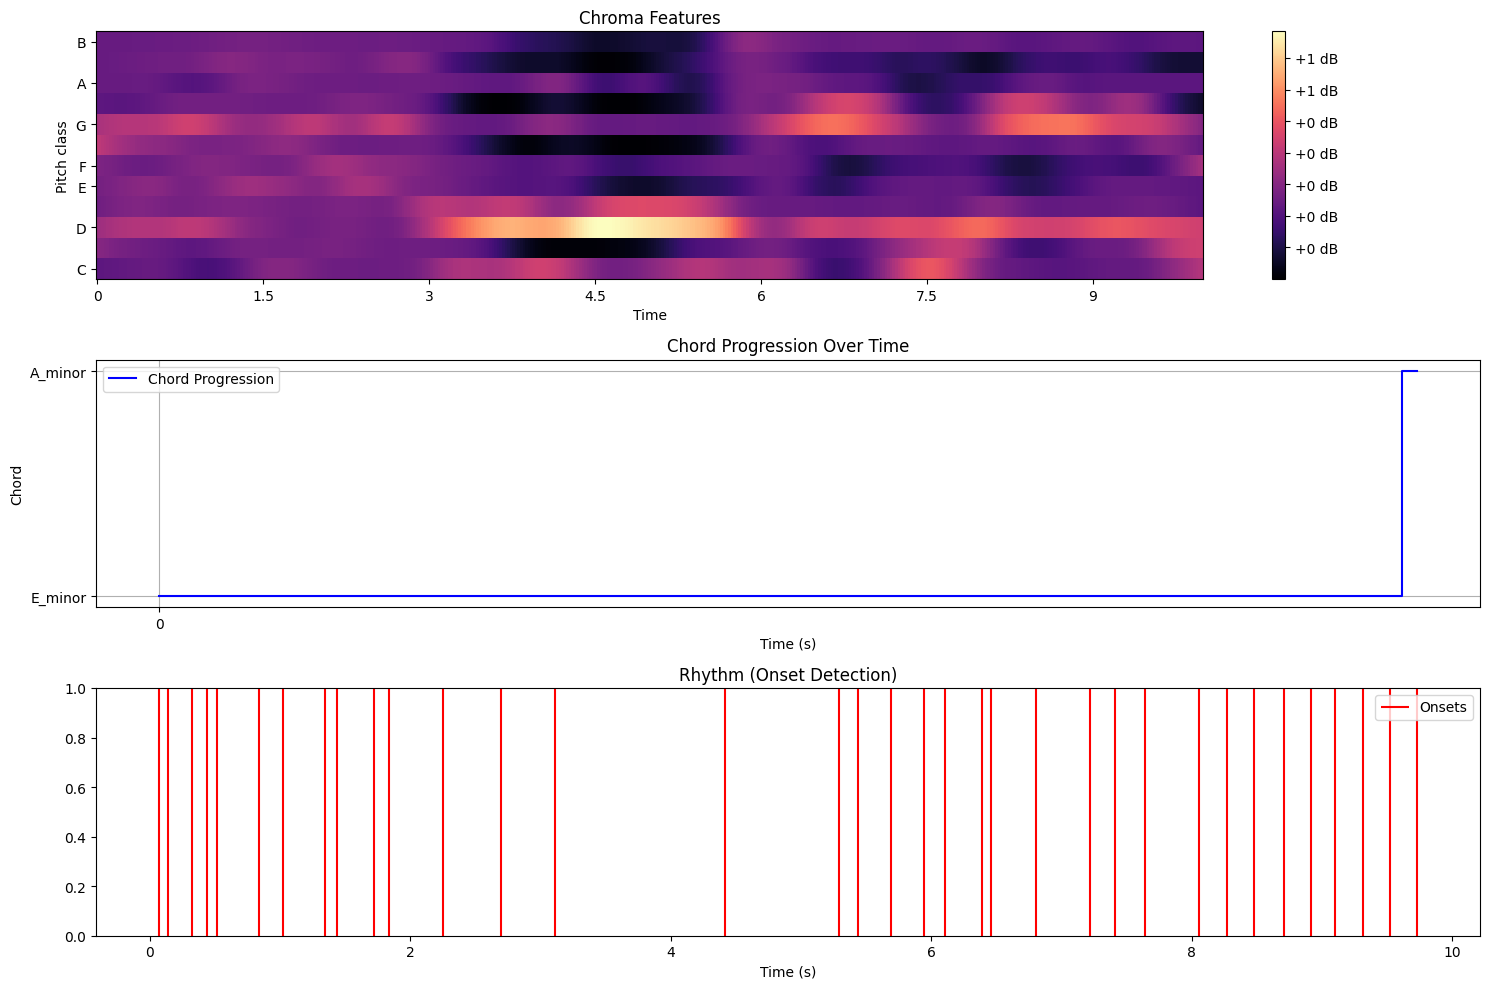

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 304.00, 平均間隔: 197.37 ms
和弦分佈： {'E_minor': 375, 'B_minor': 50, 'A_minor': 6}
和弦進行： ['E_minor -> B_minor', 'B_minor -> E_minor', 'E_minor -> B_minor', 'B_minor -> E_minor', 'E_minor -> A_minor']


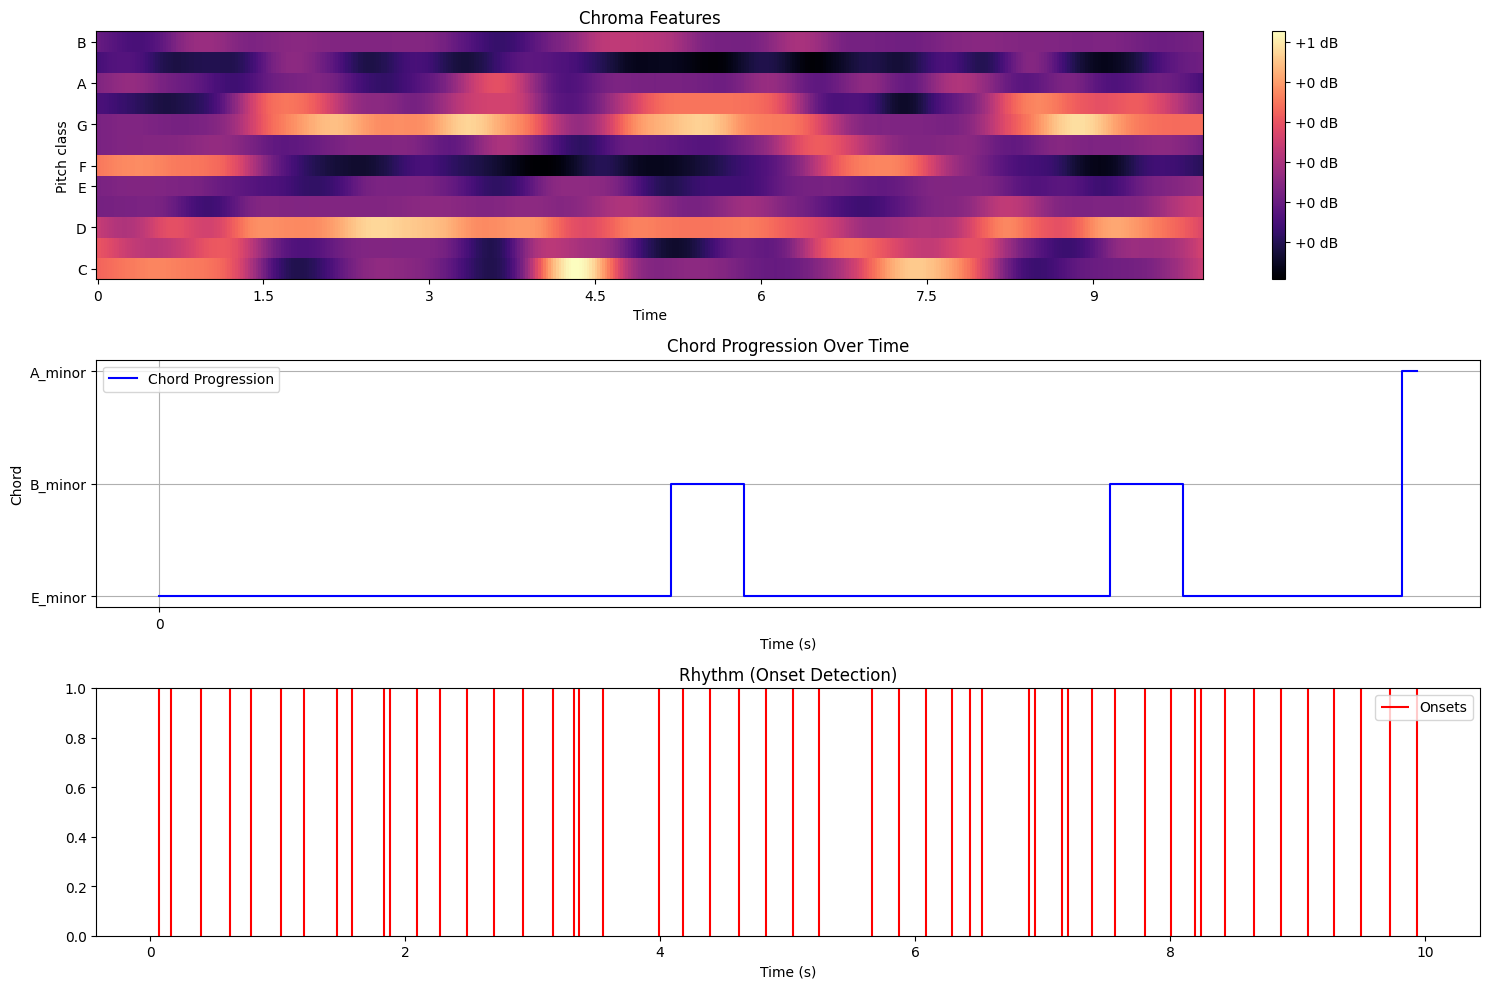

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 272.96, 平均間隔: 219.82 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


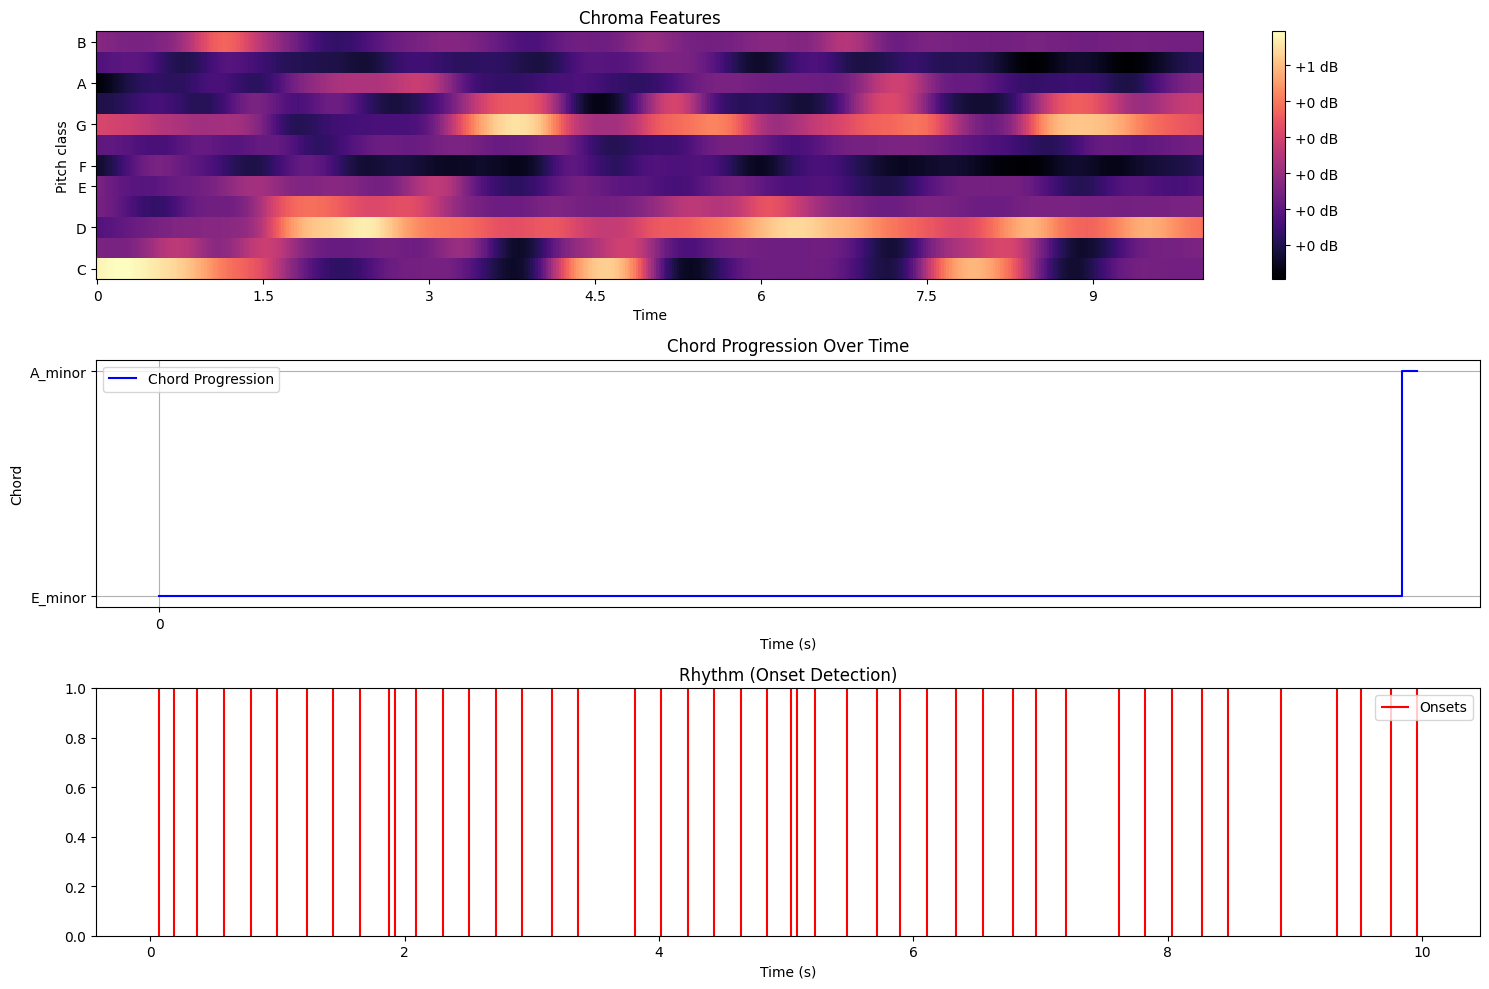

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 271.35, 平均間隔: 221.12 ms
和弦分佈： {'E_minor': 350, 'B_minor': 75, 'A_minor': 6}
和弦進行： ['E_minor -> B_minor', 'B_minor -> E_minor', 'E_minor -> B_minor', 'B_minor -> E_minor', 'E_minor -> B_minor', 'B_minor -> E_minor', 'E_minor -> A_minor']


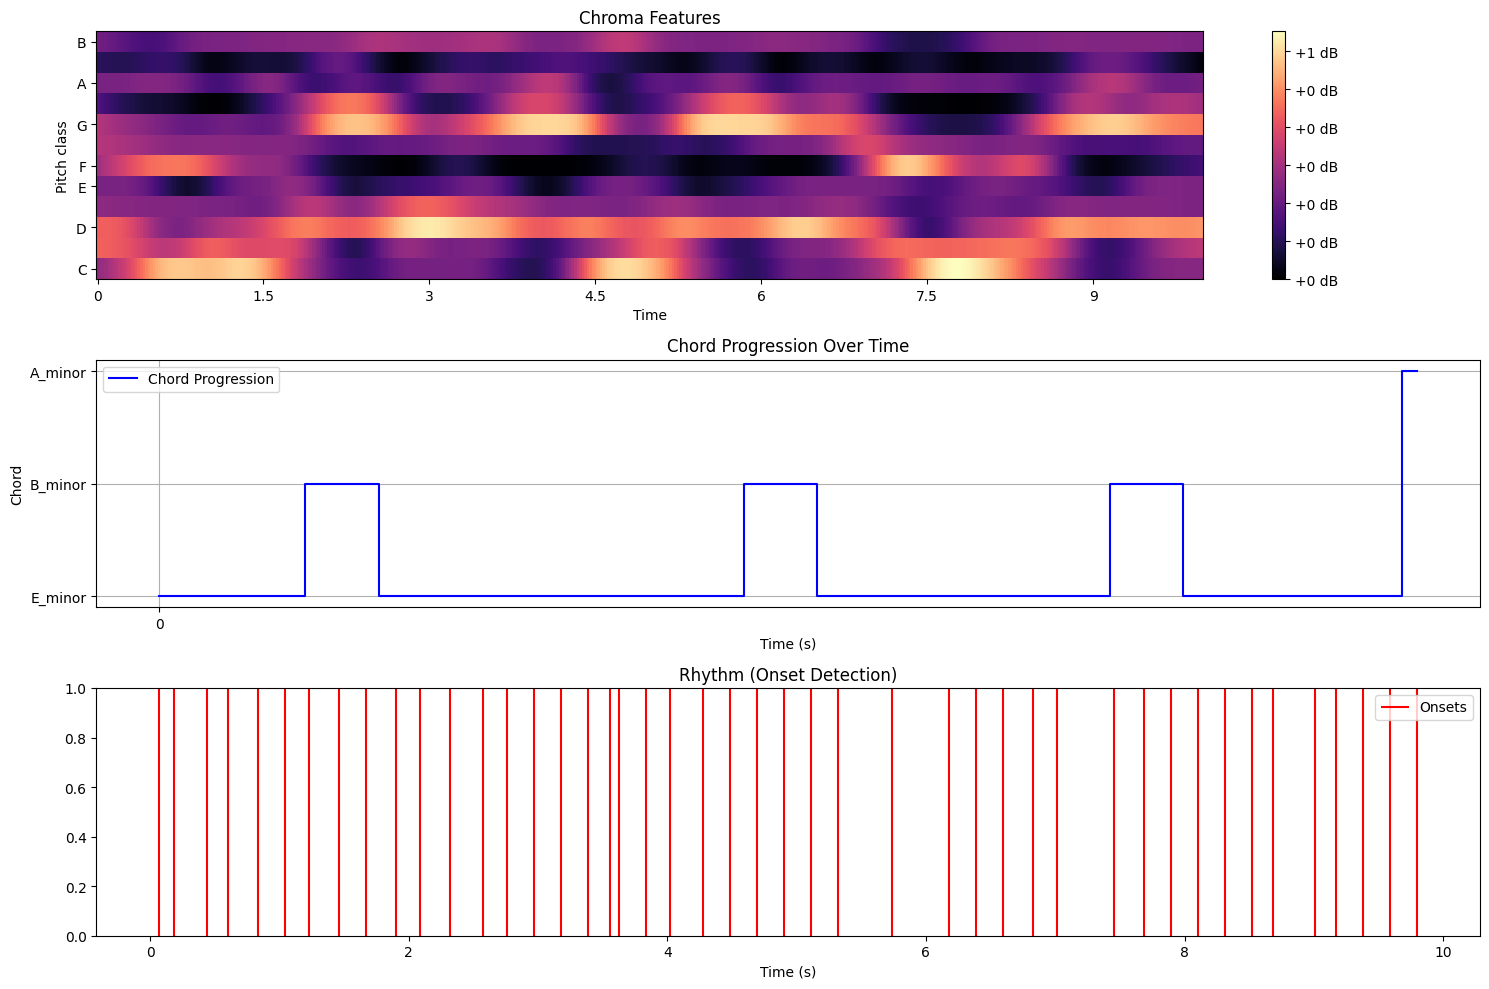

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 312.28, 平均間隔: 192.13 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


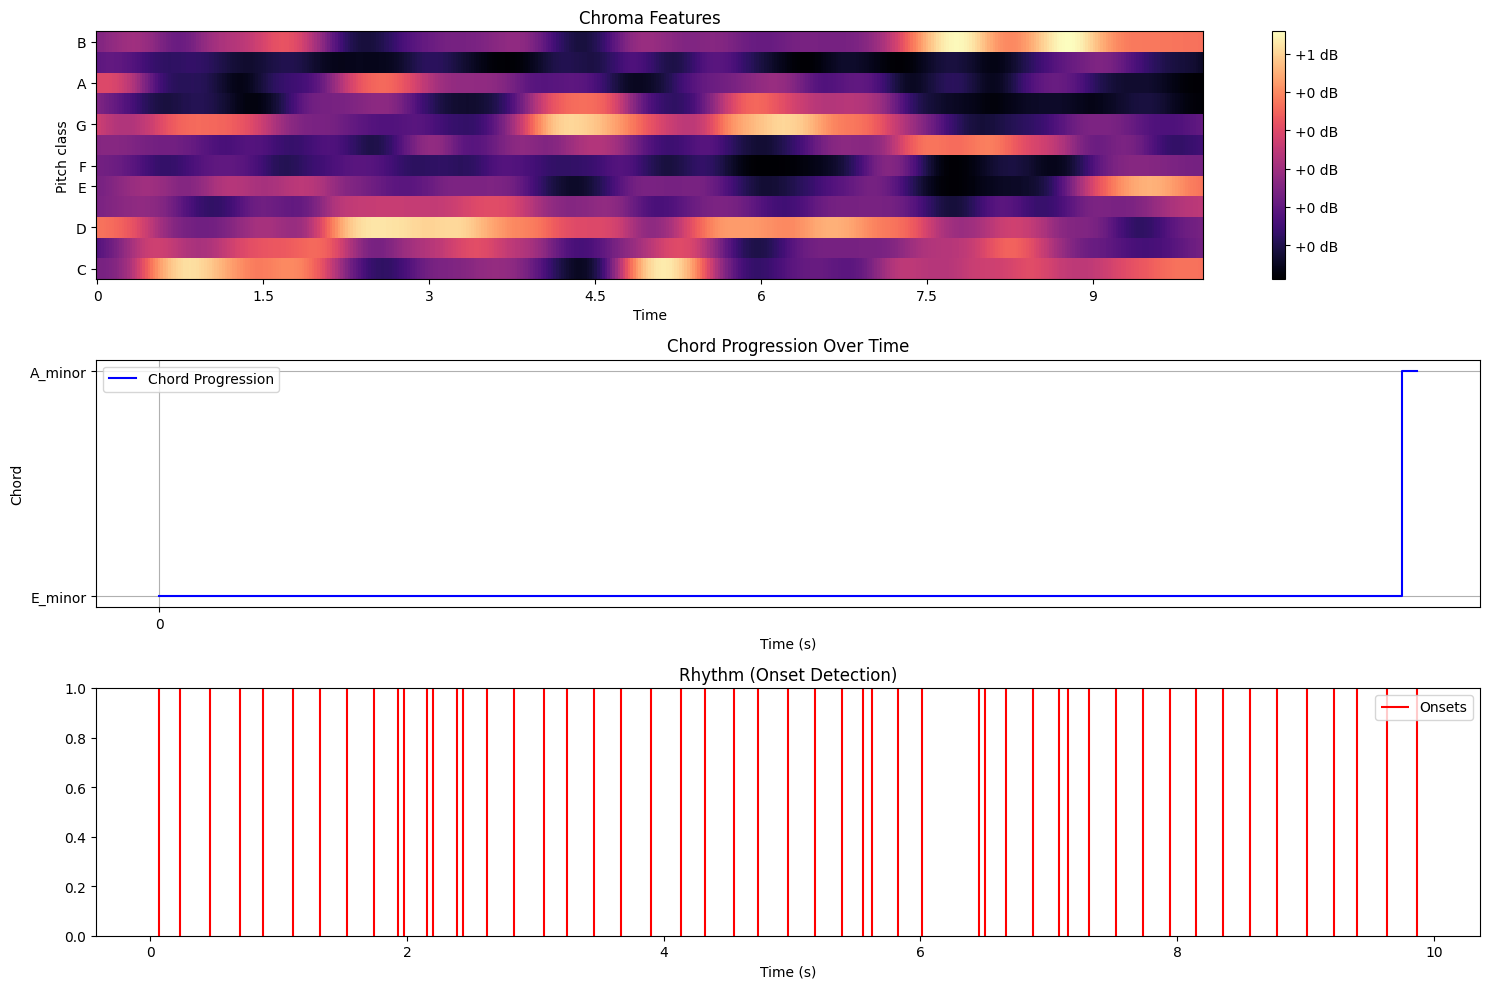

視覺化結果已保存至：/content/chord_progression.png
推測調性：B_minor
節奏分析： 估計BPM: 265.35, 平均間隔: 226.12 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


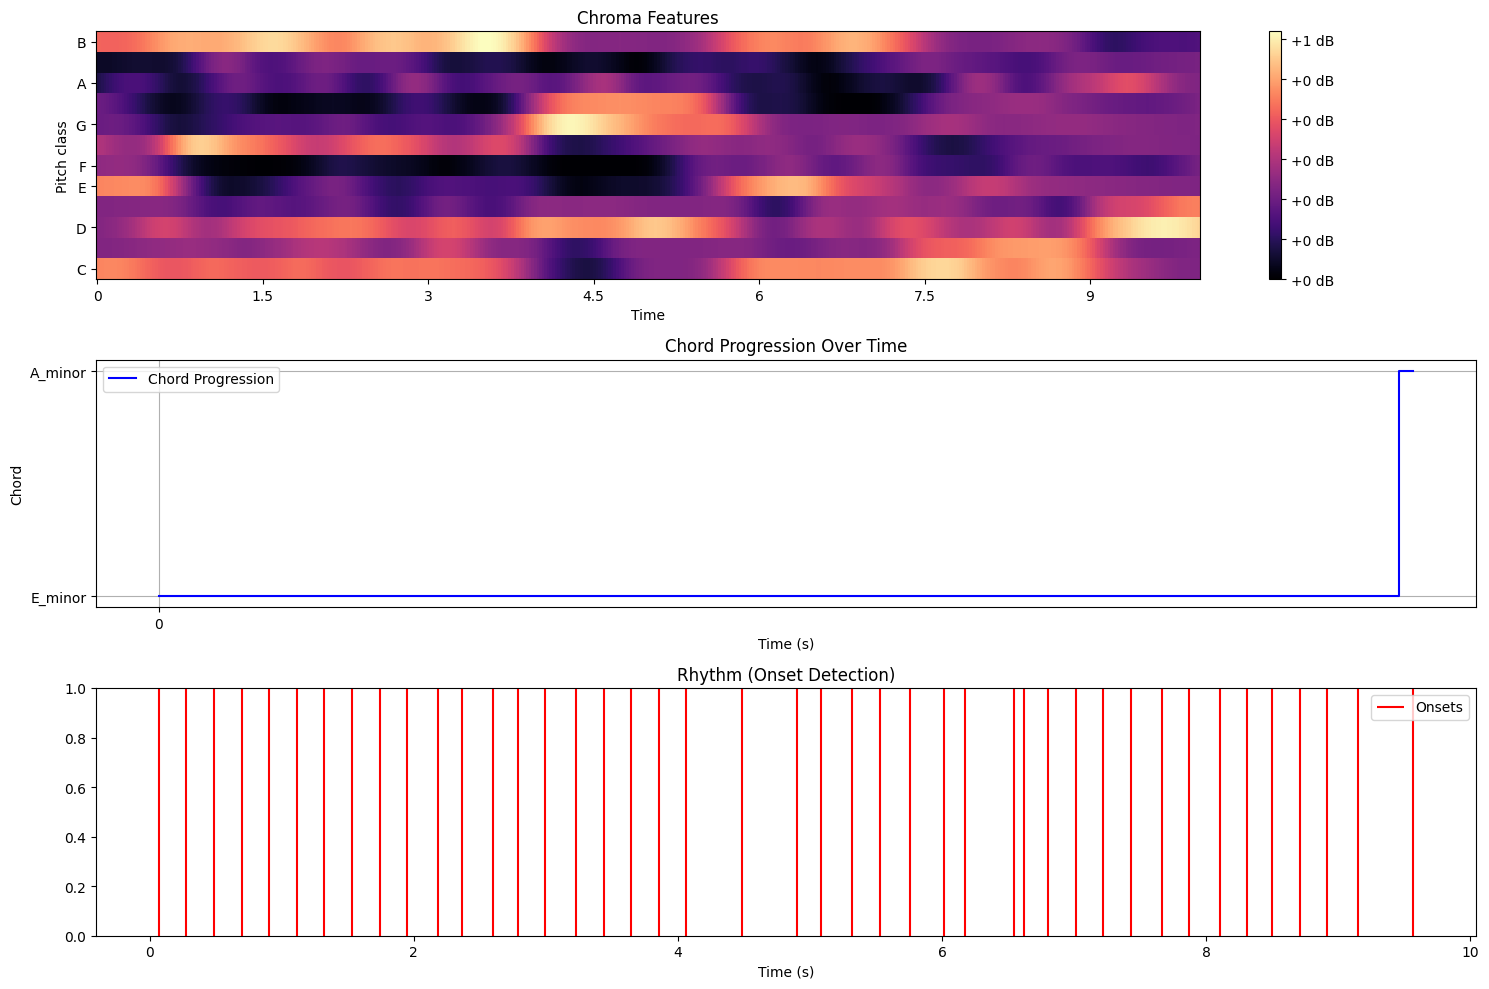

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 288.47, 平均間隔: 207.99 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


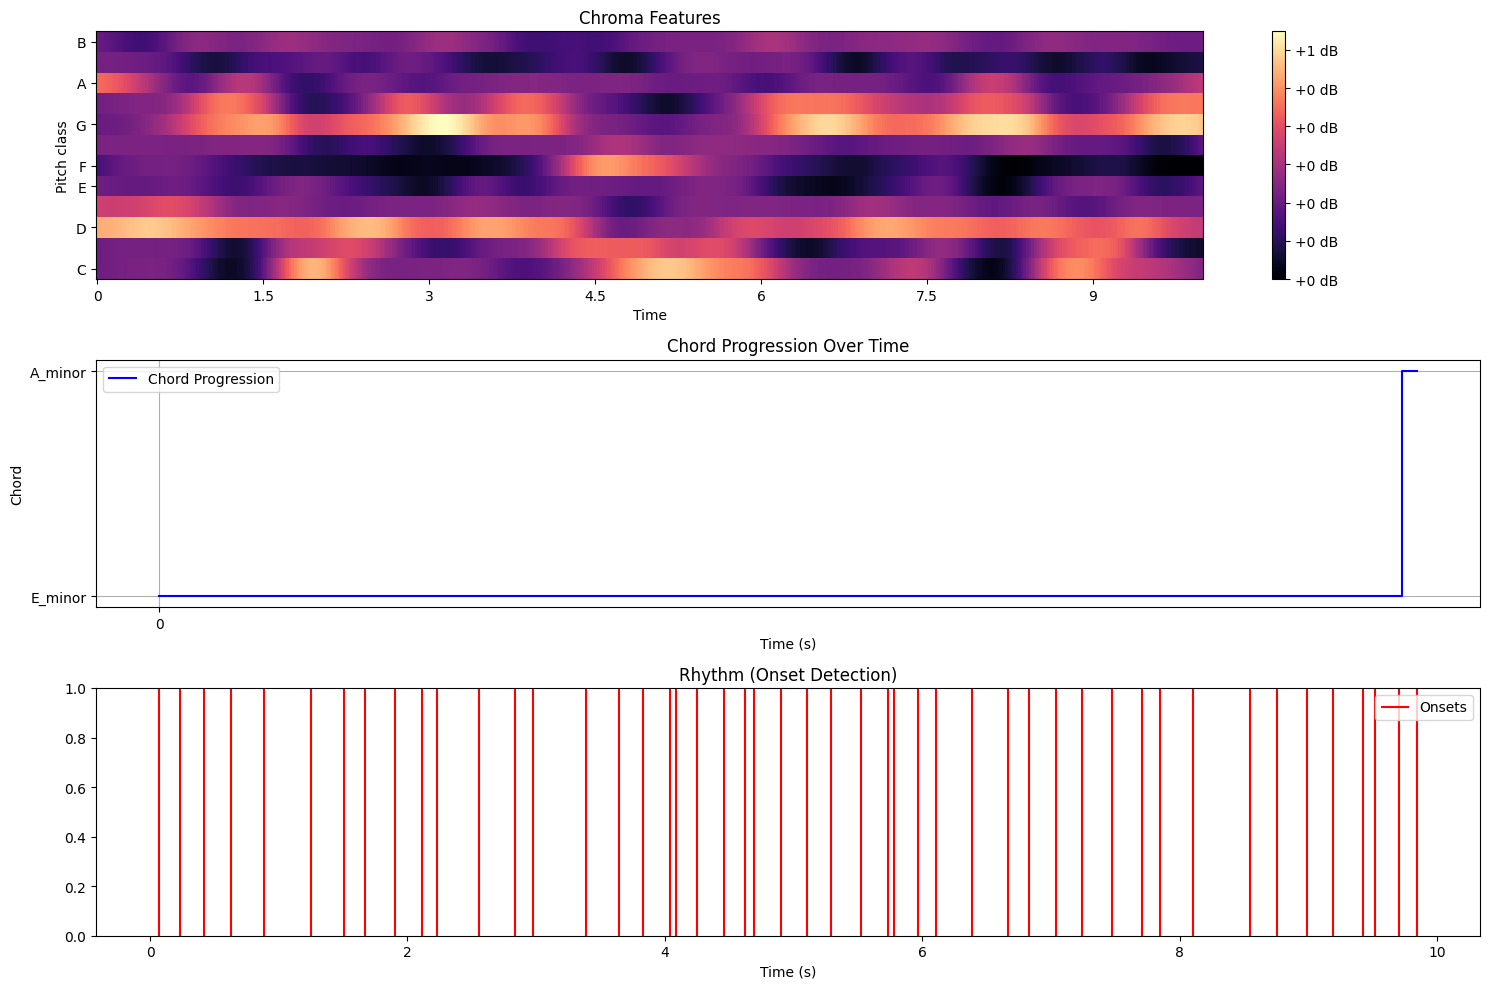

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 303.63, 平均間隔: 197.61 ms
和弦分佈： {'E_minor': 400, 'B_minor': 25, 'A_minor': 6}
和弦進行： ['E_minor -> B_minor', 'B_minor -> E_minor', 'E_minor -> A_minor']


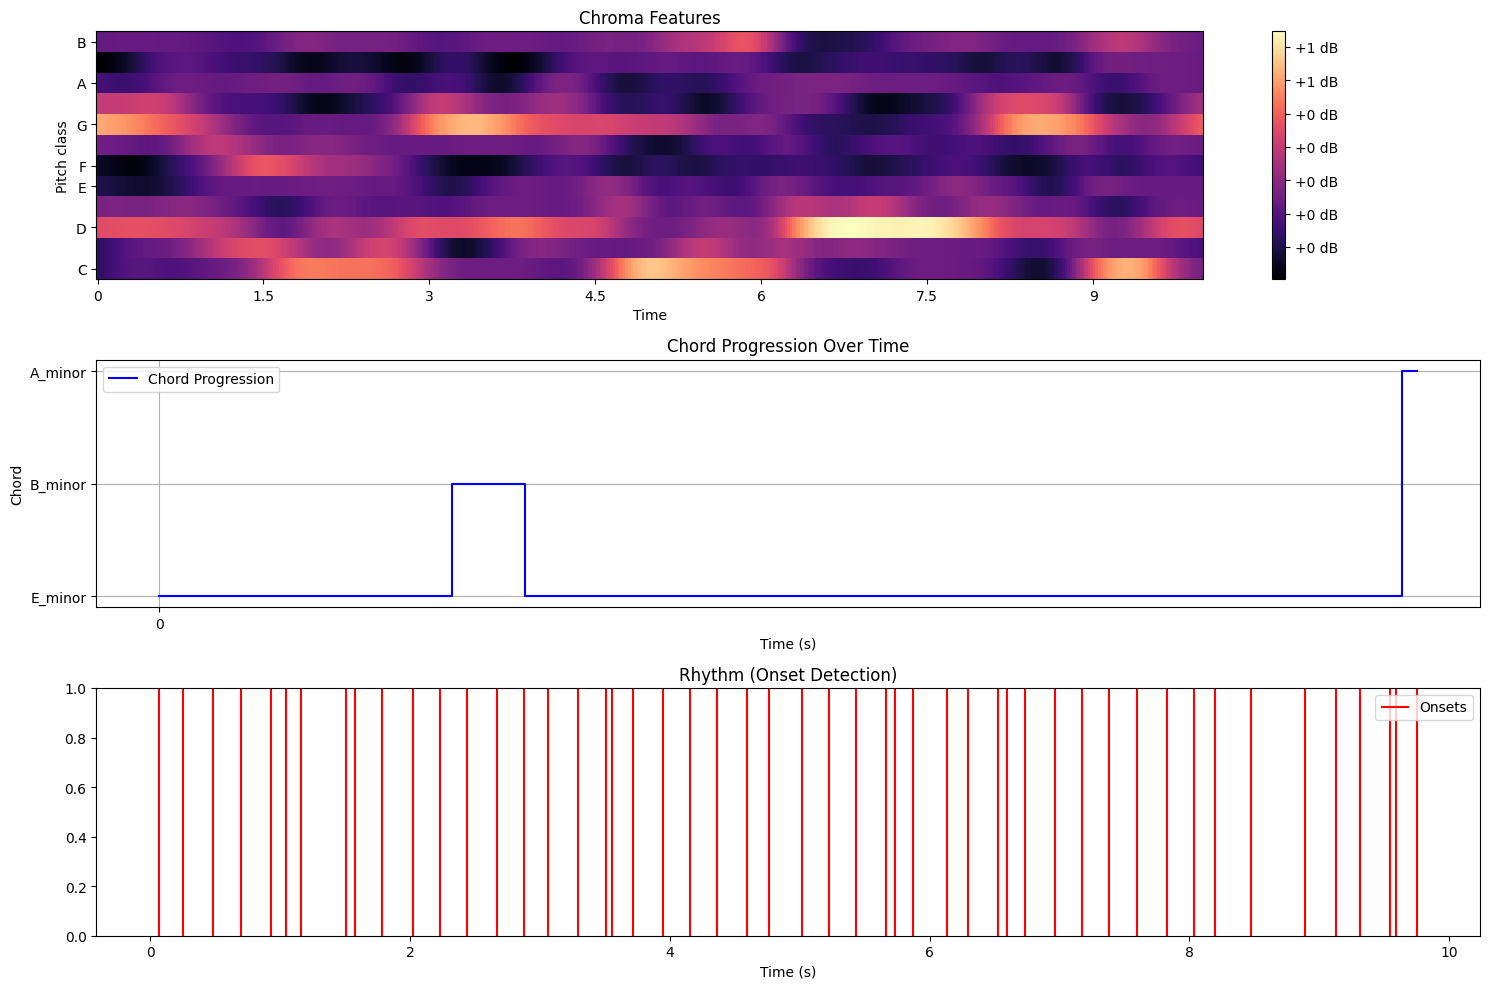

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 262.06, 平均間隔: 228.96 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


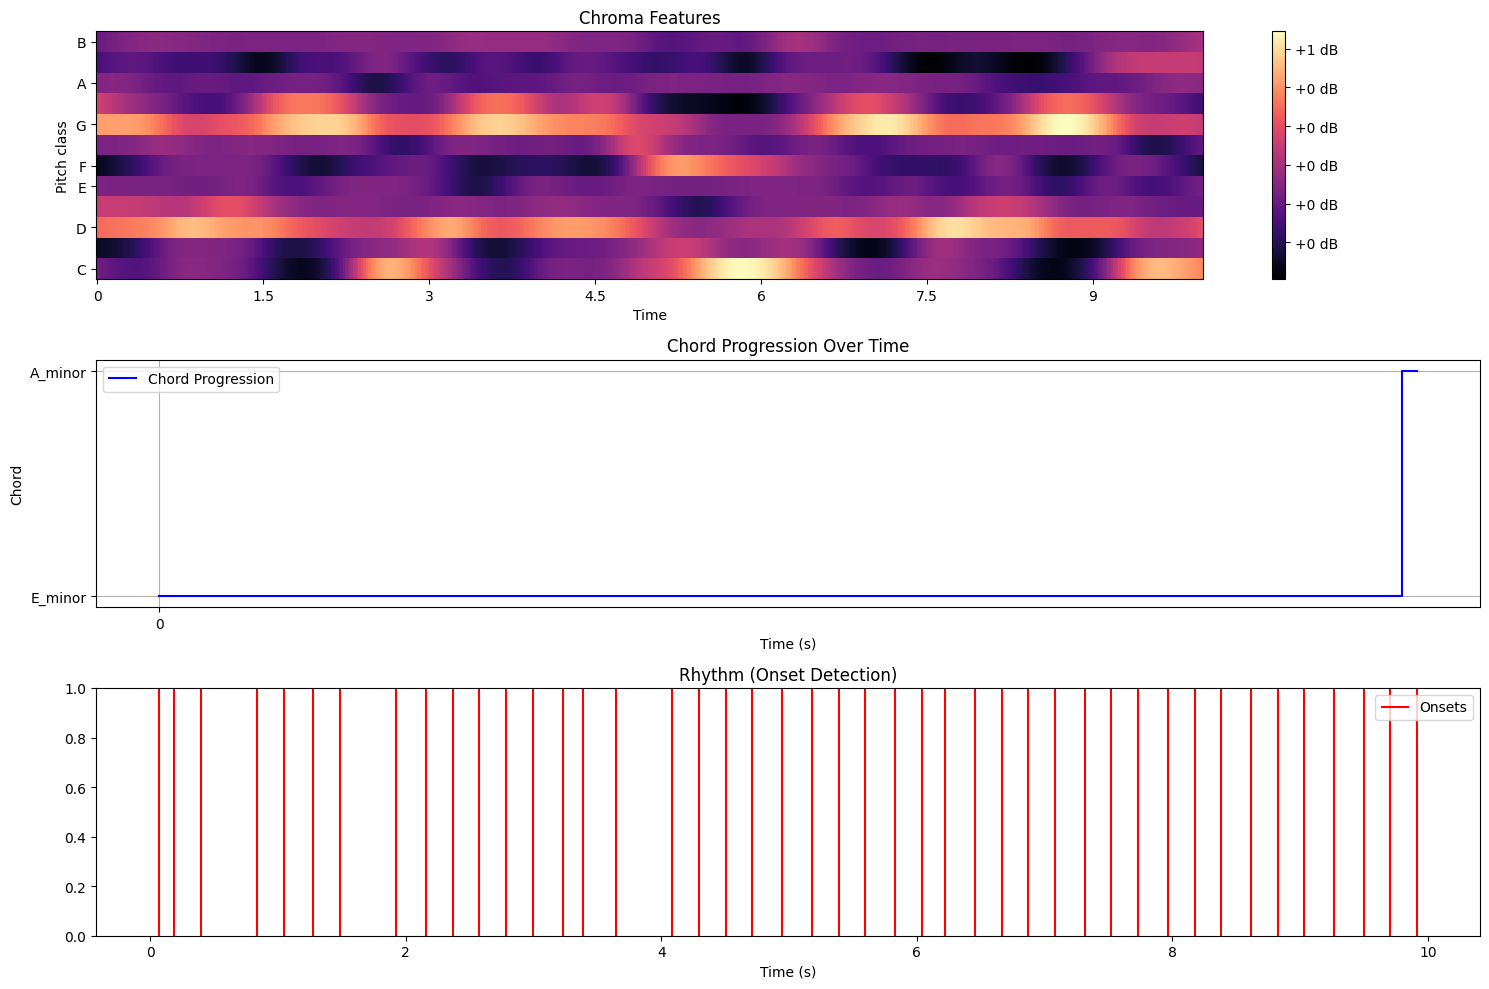

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 287.79, 平均間隔: 208.49 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


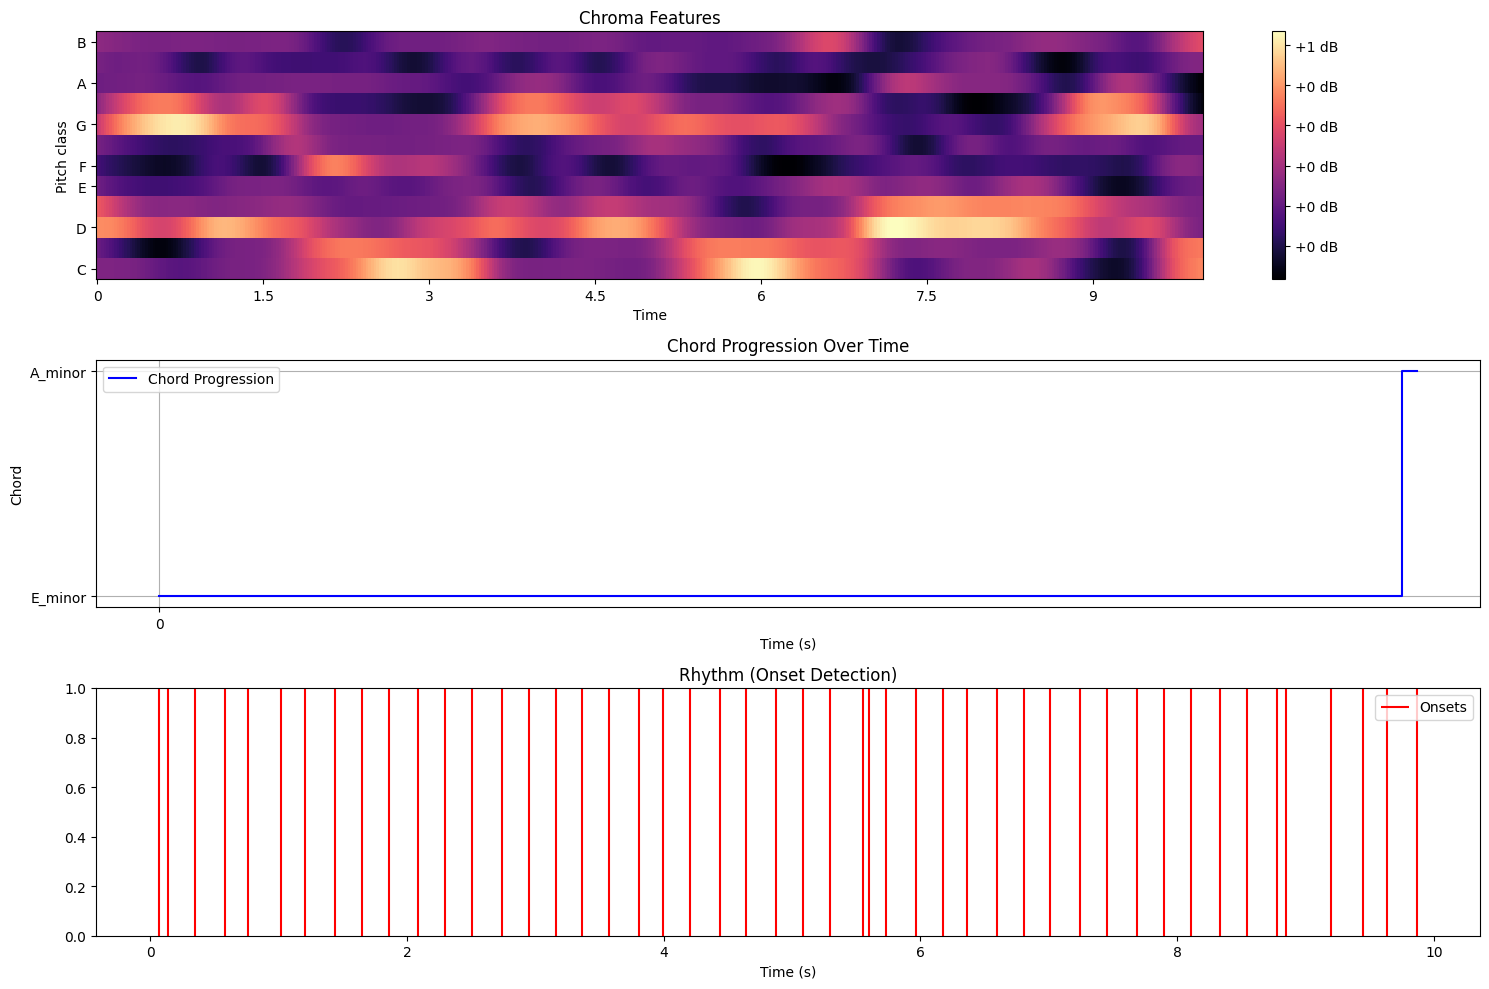

視覺化結果已保存至：/content/chord_progression.png
推測調性：B_minor
節奏分析： 估計BPM: 273.60, 平均間隔: 219.30 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


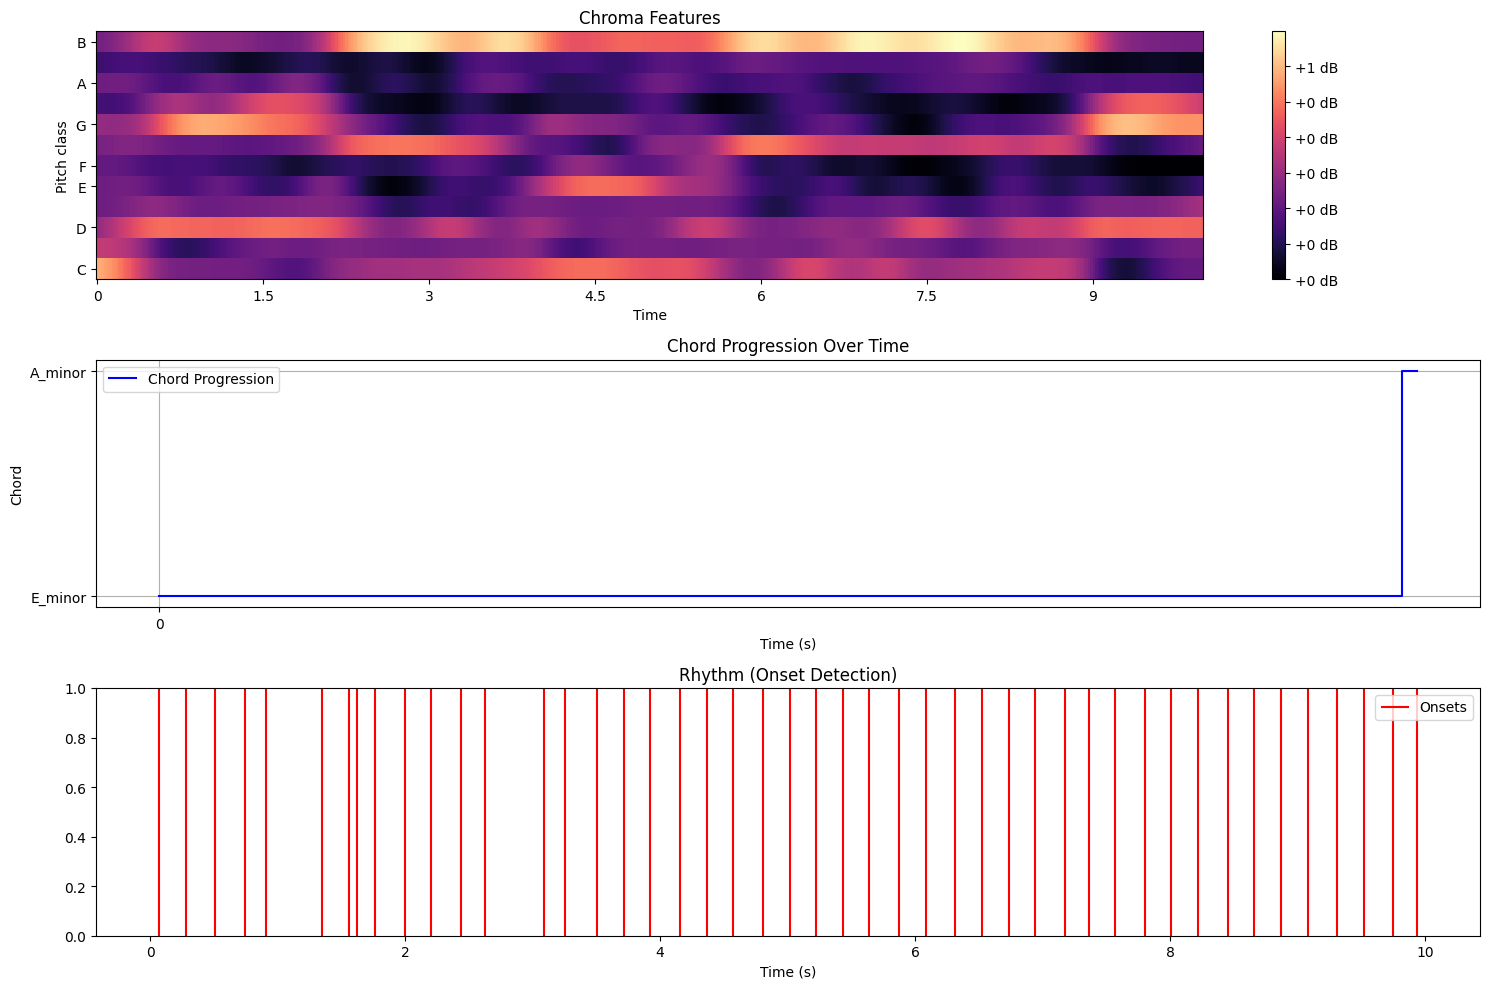

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 270.70, 平均間隔: 221.65 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


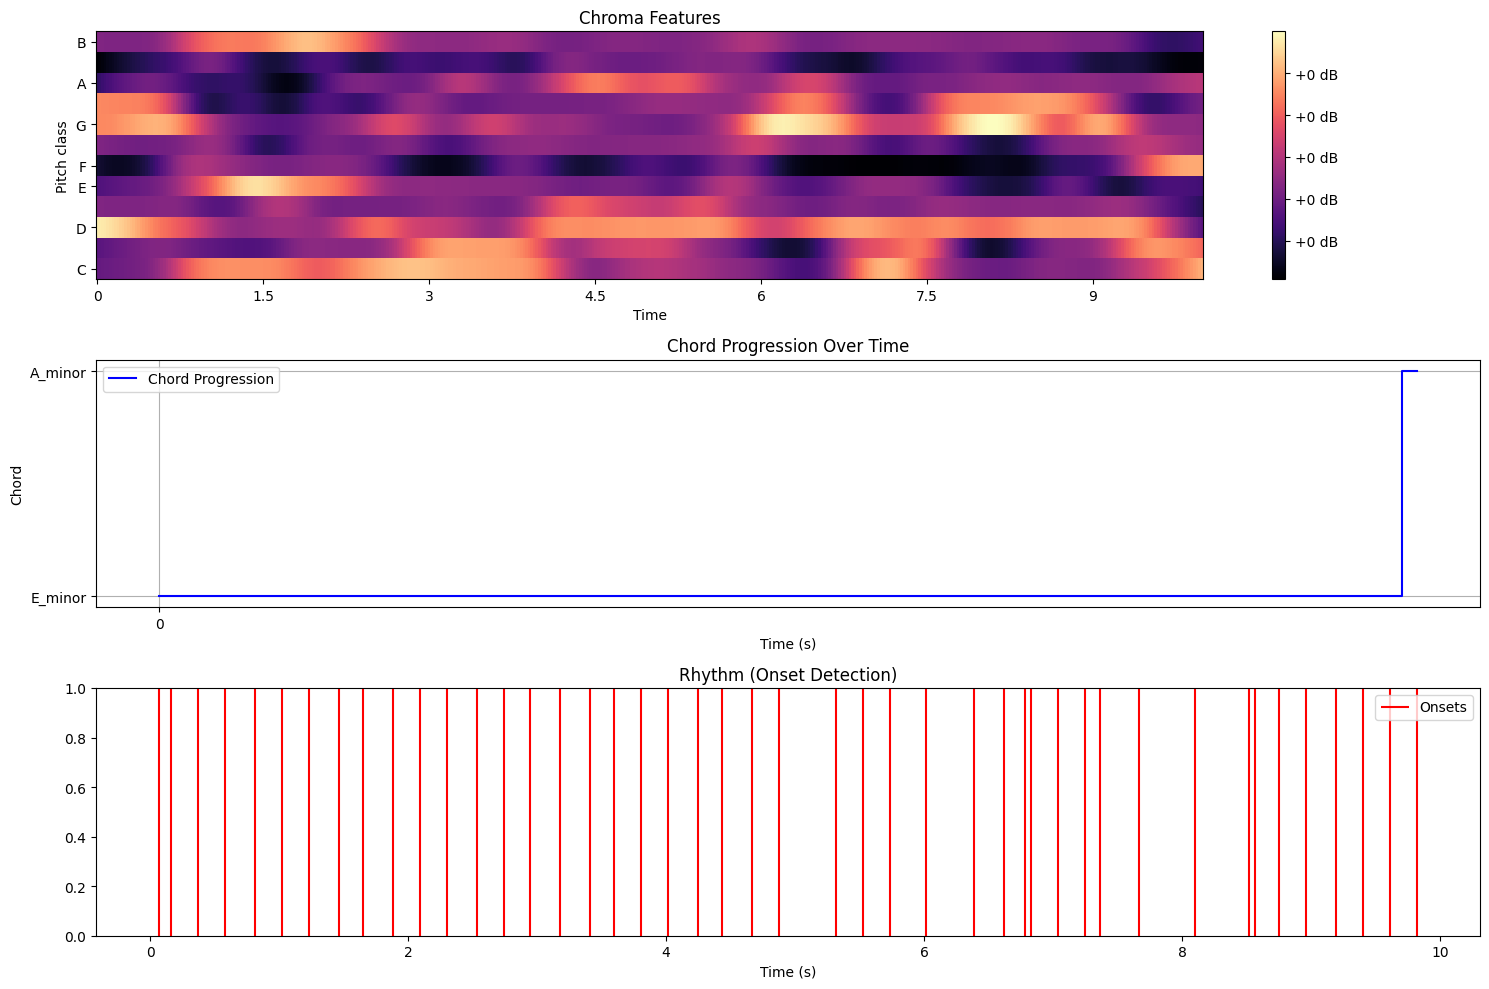

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 253.45, 平均間隔: 236.73 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


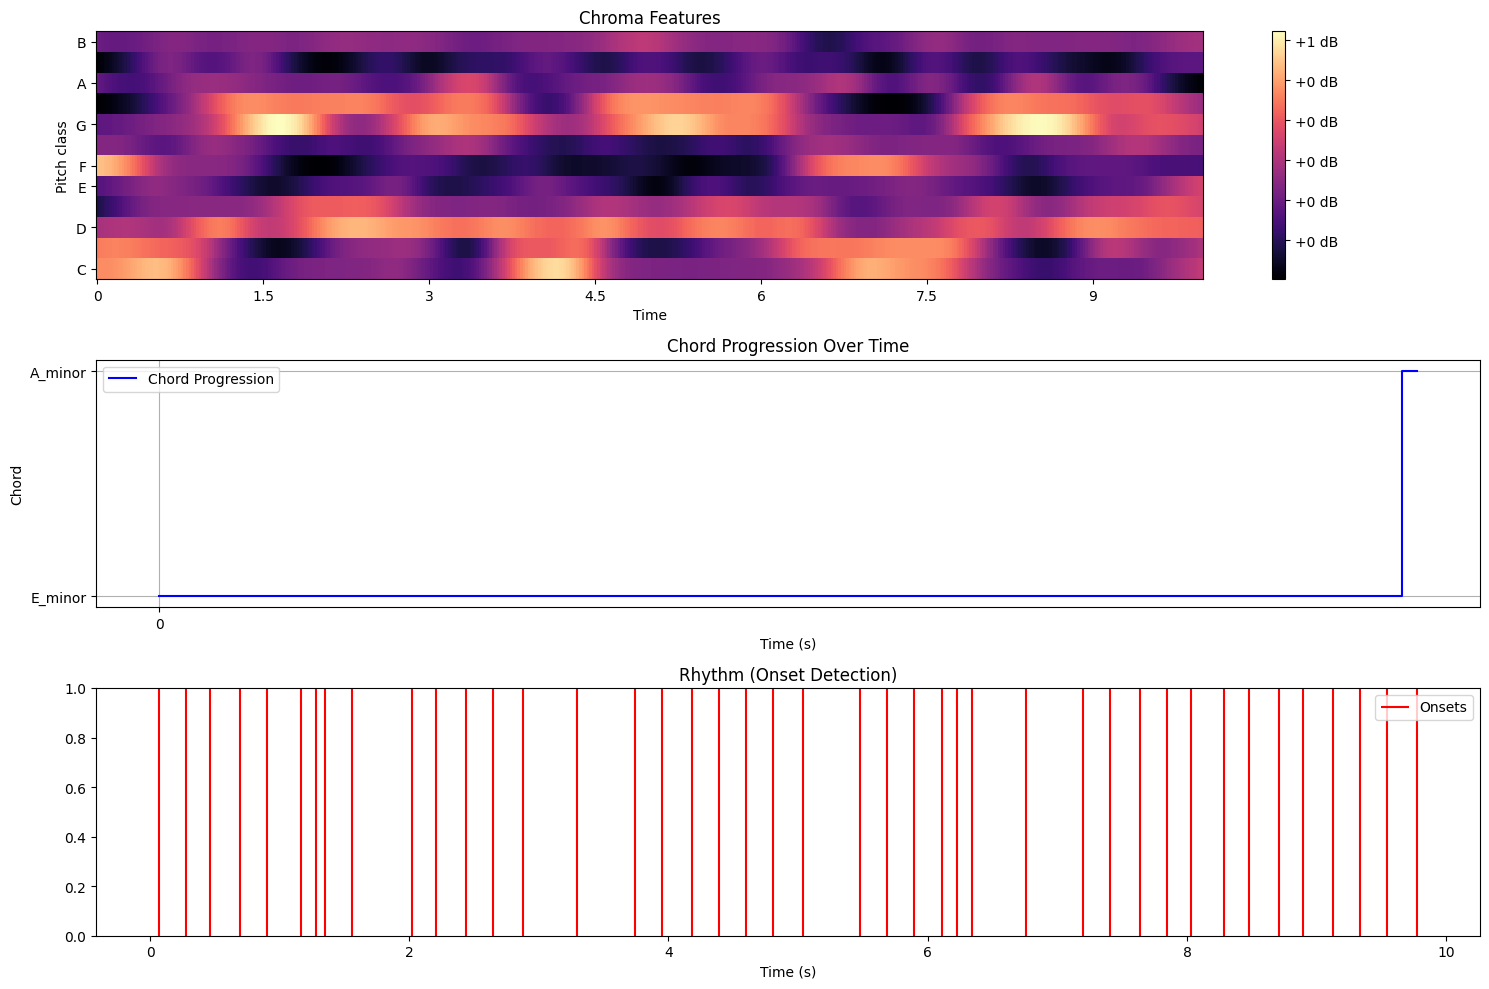

視覺化結果已保存至：/content/chord_progression.png
推測調性：G_major
節奏分析： 估計BPM: 259.02, 平均間隔: 231.65 ms
和弦分佈： {'E_minor': 425, 'A_minor': 6}
和弦進行： ['E_minor -> A_minor']


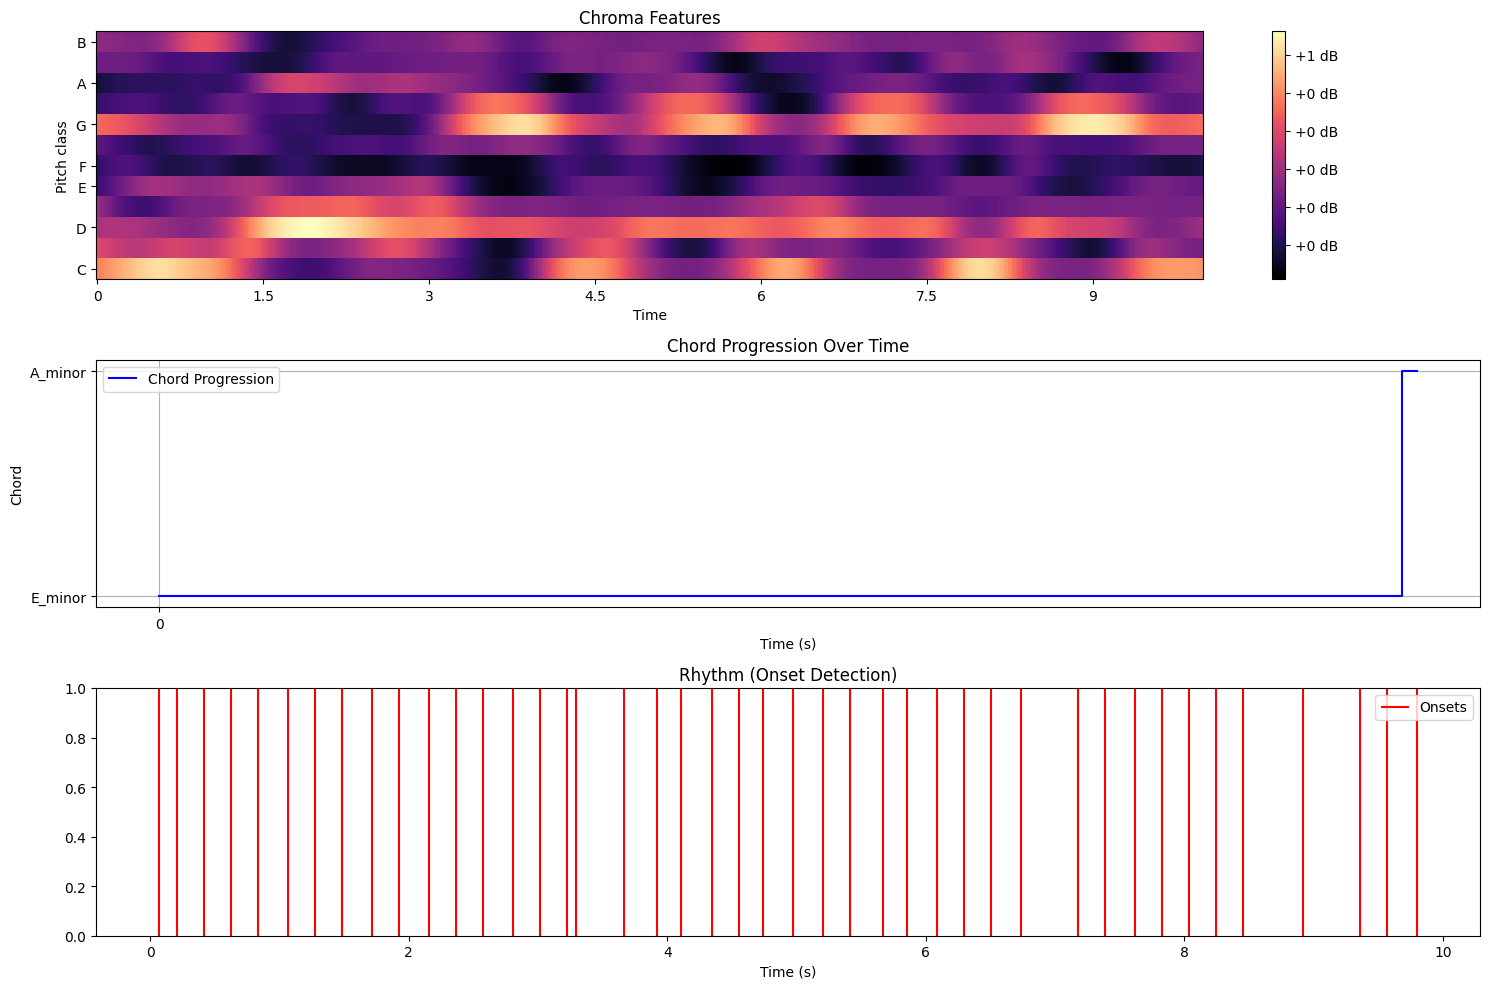

視覺化結果已保存至：/content/chord_progression.png


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import tensorflow as tf
import os
import yt_dlp

# 音級名稱
PITCH_CLASSES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

# 定義和弦列表（與訓練時一致）
chord_templates = {
    f"{root}_{typ}": np.zeros(12) for root in PITCH_CLASSES for typ in ["major", "minor", "7", "sus4"]
}
for root_idx, root in enumerate(PITCH_CLASSES):
    chord_templates[f"{root}_major"][[root_idx, (root_idx + 4) % 12, (root_idx + 7) % 12]] = 1
    chord_templates[f"{root}_minor"][[root_idx, (root_idx + 3) % 12, (root_idx + 7) % 12]] = 1
    chord_templates[f"{root}_7"][[root_idx, (root_idx + 4) % 12, (root_idx + 7) % 12, (root_idx + 10) % 12]] = 1
    chord_templates[f"{root}_sus4"][[root_idx, (root_idx + 5) % 12, (root_idx + 7) % 12]] = 1
chord_list = list(chord_templates.keys())

# 步驟 1: 加載預訓練模型
def load_trained_model(model_path="/content/drive/MyDrive/chord_model.keras"):
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"模型檔案 {model_path} 不存在！請先訓練並保存模型。")
    model = tf.keras.models.load_model(model_path)
    # 重新編譯模型以重建 compile_metrics（解決可能的警告）
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    print(f"模型已從 {model_path} 加載並重新編譯")
    return model

# 步驟 2: 實時音訊處理
def process_streaming_audio(audio_path, chunk_duration=10.0):
    y, sr = librosa.load(audio_path)
    chunk_size = int(chunk_duration * sr)
    for start in range(0, len(y), chunk_size):
        chunk = y[start:start + chunk_size]
        if len(chunk) == chunk_size:
            yield chunk, sr
        else:
            break

# 步驟 3: 檢測和弦
def detect_chords(chunk, sr, model, chord_list, max_length=50, window_hop=25):
    chroma = librosa.feature.chroma_cens(y=chunk, sr=sr, hop_length=512)
    times = librosa.times_like(chroma, sr=sr, hop_length=512)

    # 將 chroma 分成多個窗口，每個窗口長度為 max_length，步幅為 window_hop
    chroma_transposed = chroma.T  # (time_steps, 12)
    num_frames = chroma_transposed.shape[0]
    chord_indices = []

    # 遍歷時間步，生成每個窗口的預測
    for start in range(0, num_frames, window_hop):
        end = start + max_length
        if end > num_frames:
            # 如果窗口不足 max_length，進行填充
            window = chroma_transposed[start:num_frames]
            pad_width = ((0, max_length - window.shape[0]), (0, 0))
            window = np.pad(window, pad_width, mode='constant', constant_values=0)
        else:
            window = chroma_transposed[start:end]

        # 重塑窗口為 (1, max_length, 12, 1)
        window = window[np.newaxis, :, :, np.newaxis]  # (1, max_length, 12, 1)
        probabilities = model.predict(window, verbose=0)  # (1, n_classes)
        chord_idx = np.argmax(probabilities, axis=1)[0]  # 純量
        chord_indices.append(chord_idx)

    # 根據 times 長度擴展 chord_indices
    chord_labels = []
    for i in range(len(times)):
        # 計算對應的窗口索引
        window_idx = min(i // window_hop, len(chord_indices) - 1)
        chord_idx = chord_indices[window_idx]
        if chord_idx < len(chord_list):
            chord_labels.append(chord_list[chord_idx])
        else:
            chord_labels.append('N/A')

    # 平滑處理
    window_size = 5
    smoothed_chords = []
    for i in range(len(chord_labels)):
        start = max(0, i - window_size // 2)
        end = min(len(chord_labels), i + window_size // 2 + 1)
        window = chord_labels[start:end]
        valid_window = [chord for chord in window if chord != 'N/A']
        if valid_window:
            most_common = Counter(valid_window).most_common(1)[0][0]
            smoothed_chords.append(most_common)
        else:
            smoothed_chords.append('N/A')

    return times, smoothed_chords, chroma

# 步驟 4: 調性檢測
def detect_key(chroma):
    key_profiles = {f"{root}_{mode}": np.roll(profile, PITCH_CLASSES.index(root))
                    for root in PITCH_CLASSES
                    for mode, profile in [("major", [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]),
                                         ("minor", [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])]}

    pitch_distribution = np.mean(chroma, axis=1)
    pitch_distribution = pitch_distribution / (np.sum(pitch_distribution) + 1e-6)

    best_key = 'Unknown'
    max_corr = -1
    for key, profile in key_profiles.items():
        corr = np.corrcoef(pitch_distribution, profile / np.sum(profile))[0, 1]
        if corr > max_corr:
            max_corr = corr
            best_key = key
    return best_key

# 步驟 5: 節奏分析
def detect_rhythm(chunk, sr, chords, times):
    onsets = librosa.onset.onset_detect(y=chunk, sr=sr, units='time')
    if len(onsets) < 2:
        return "無法檢測節奏", onsets

    intervals = np.diff(onsets) * 1000
    avg_interval = np.mean(intervals)
    bpm = 60000 / avg_interval if avg_interval > 0 else 0
    return f"估計BPM: {bpm:.2f}, 平均間隔: {avg_interval:.2f} ms", onsets

# 步驟 6: 分析和視覺化
def analyze_and_visualize(times, chords, chroma, sr, duration, onsets, output_path="/content/chord_progression.png"):
    valid_chords = [(t, c) for t, c in zip(times, chords) if c != 'N/A']
    if not valid_chords:
        print("未檢測到有效和弦！")
        return

    chord_times, chord_labels = zip(*valid_chords)

    chord_counts = Counter(chord_labels)
    print("和弦分佈：", dict(chord_counts))

    progression = []
    for i in range(len(chord_labels) - 1):
        if chord_labels[i] != chord_labels[i + 1]:
            progression.append(f"{chord_labels[i]} -> {chord_labels[i + 1]}")
    print("和弦進行：", progression)

    plt.figure(figsize=(15, 10))
    plt.subplot(3, 1, 1)
    librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', hop_length=512)
    plt.colorbar(format='%+2.0f dB')
    plt.title("Chroma Features")

    plt.subplot(3, 1, 2)
    plt.step(chord_times, chord_labels, where='post', color='blue', label='Chord Progression')
    plt.xlabel("Time (s)")
    plt.ylabel("Chord")
    plt.title("Chord Progression Over Time")
    plt.xticks(np.arange(0, duration, step=10))
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.vlines(onsets, 0, 1, colors='r', label='Onsets')
    plt.xlabel("Time (s)")
    plt.title("Rhythm (Onset Detection)")
    plt.legend()
    plt.ylim(0, 1)

    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    print(f"視覺化結果已保存至：{output_path}")

# 步驟 7: 主函數（僅分析）
def analyze_never_gonna_give_you_up(audio_path, output_path="/content/chord_progression.png", streaming=True):
    if not os.path.exists(audio_path):
        print(f"錯誤：找不到音訊檔案 {audio_path}")
        return

    # 加載預訓練模型
    model = load_trained_model("/content/drive/MyDrive/chord_model.keras")

    if streaming:
        for chunk, sr in process_streaming_audio(audio_path):
            times, chords, chroma = detect_chords(chunk, sr, model, chord_list)
            key = detect_key(chroma)
            print(f"推測調性：{key}")
            rhythm, onsets = detect_rhythm(chunk, sr, chords, times)
            print("節奏分析：", rhythm)
            analyze_and_visualize(times, chords, chroma, sr, duration=10.0, onsets=onsets, output_path=output_path)  # 修正為 duration
    else:
        y, sr = librosa.load(audio_path)
        duration = len(y) / sr
        times, chords, chroma = detect_chords(y, sr, model, chord_list)
        key = detect_key(chroma)
        print(f"推測調性：{key}")
        rhythm, onsets = detect_rhythm(y, sr, chords, times)
        print("節奏分析：", rhythm)
        analyze_and_visualize(times, chords, chroma, sr, duration=duration, onsets=onsets, output_path=output_path)

# 執行範例
if __name__ == "__main__":
    audio_path = "/content/drive/MyDrive/audio/A Hard Day's Night.mp3"
    analyze_never_gonna_give_you_up(audio_path=audio_path, streaming=True)